In [1]:
'''
Author: zhangshd
Date: 2025-05-16
Description: Example Jupyter notebook demonstrating interactive visualization of atom importance
'''
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
ROOT_DIR = Path(".").resolve().parent
sys.path.append(str(ROOT_DIR))

# Import necessary modules
from src.cgcnn.visualization.atom_visualizer import AtomImportanceVisualizer
from src.cgcnn.module.att_cgcnn import CrystalGraphConvNet
from src.cgcnn.inference import InferenceDataset
from src.cgcnn.utils import load_model_from_dir
import traceback

# Set matplotlib to show plots inline
%matplotlib inline

In [2]:
# Introduction
print("# Interactive Atom Importance Visualization Demo")
print("This notebook demonstrates how to use NGLView for interactive visualization of atom importance in MOF structures.")
print("\n## 1. Load Model and Dataset")

# Load model
model_path = ROOT_DIR/'results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43'
model_checkpoint = list(model_path.glob('*/best*.ckpt'))[0]
print(f"Loading model from: {model_checkpoint}")

def load_model(checkpoint_path):
    """Load a trained CrystalGraphConvNet model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    
    # Initialize model
    model = CrystalGraphConvNet(**checkpoint["hyper_parameters"])
    
    # Load state dict
    model.load_state_dict({k.replace("model.", ""):v for k,v in checkpoint['state_dict'].items()})
    model.eval()
    
    return model

try:
    # model = load_model(model_checkpoint)
    model, trainer = load_model_from_dir(model_path, accelerator="cpu")
    print(f"Model loaded successfully")
    print(f"Task types: {model.hparams['task_types']}")
    print(f"Using attention pooling: {model.hparams['att_pooling']}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please update the path to your trained model and try again")

# Interactive Atom Importance Visualization Demo
This notebook demonstrates how to use NGLView for interactive visualization of atom importance in MOF structures.

## 1. Load Model and Dataset
Loading model from: /home/zhangsd/repos/MOFSNN/results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43/checkpoints/best-epoch=108-val_Metric=0.608.ckpt
task_types:  ['regression', 'classification', 'classification', 'classification_4', 'classification', 'classification', 'classification']


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Loading the best model checkpoint: /home/zhangsd/repos/MOFSNN/results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43/checkpoints/best-epoch=108-val_Metric=0.608.ckpt
Model loaded successfully
Task types: ['regression', 'classification', 'classification', 'classification_4', 'classification', 'classification', 'classification']
Using attention pooling: False


In [3]:
# Load example CIF file
print("\n## 2. Load MOF Structure")
cif_dir = ROOT_DIR/'data/example_cifs'
print(f"Looking for CIF files in: {cif_dir}")
cif_files = list(cif_dir.glob('*.cif'))

# Select a CIF file
# cif_path = str(cif_files[0])
cif_path = ROOT_DIR/'data/example_cifs/CALF20.cif'
# cif_path = ROOT_DIR/'data/example_cifs/Cu-BTC.cif'
print(f"Using CIF file: {cif_path}")

# Create inference dataset
def load_dataset(cif_path):
    """Load data from a CIF file"""
    temp_dir = Path('./temp_inference')
    temp_dir.mkdir(exist_ok=True)
    
    dataset = InferenceDataset(
        [cif_path], 
        saved_dir=temp_dir,
        **{k:v for k,v in model.hparams.items() if k not in ["saved_dir"]},
    )
    
    dataset.setup()
    return dataset

dataset = load_dataset(cif_path)
print(f"CIF data loaded successfully")


## 2. Load MOF Structure
Looking for CIF files in: /home/zhangsd/repos/MOFSNN/data/example_cifs
Using CIF file: /home/zhangsd/repos/MOFSNN/data/example_cifs/CALF20.cif
CIF data loaded successfully


In [4]:
# Process data
print("\n## 3. Prepare Data for Visualization")

# Get data for the structure
data_dict = dataset[0]
atom_fea = data_dict["atom_fea"] 
nbr_fea = data_dict["nbr_fea"]
nbr_fea_idx = data_dict["nbr_fea_idx"]
extra_fea = data_dict["extra_fea"]
cif_id = data_dict["cif_id"]

# Get atom coordinates and elements
from ase.io import read
structure = read(cif_path)
atom_coords = structure.get_positions()
atom_elements = structure.get_chemical_symbols()

# Process into a batch
data_batch = dataset.collate([data_dict])
atom_fea_batch = data_batch["atom_fea"]
nbr_fea_batch = data_batch["nbr_fea"]
nbr_fea_idx_batch = data_batch["nbr_fea_idx"]
crystal_atom_idx_batch = data_batch["crystal_atom_idx"]



## 3. Prepare Data for Visualization


In [5]:
model.eval()
out, _ = model(data_batch)

print(out)

[tensor([[0.4418]], grad_fn=<AddmmBackward0>), tensor([[-1.9591, -0.1520]], grad_fn=<LogSoftmaxBackward0>), tensor([[-7.8864e+00, -3.7592e-04]], grad_fn=<LogSoftmaxBackward0>), tensor([[-8.3170, -5.6985, -0.0229, -3.9610]], grad_fn=<LogSoftmaxBackward0>), tensor([[-1.0178, -0.4485]], grad_fn=<LogSoftmaxBackward0>), tensor([[-2.3565, -0.0995]], grad_fn=<LogSoftmaxBackward0>), tensor([[-1.9896, -0.1470]], grad_fn=<LogSoftmaxBackward0>)]


In [6]:
# Create visualizer
model = model.model
visualizer = AtomImportanceVisualizer(model)

print("\n## 4. Calculate Atom Importance")
# Calculate atom importance for all tasks
task_results = {}
for task_idx in range(len(model.task_types)):
    result = visualizer.calculate_atom_importance(
        atom_fea_batch, nbr_fea_batch, nbr_fea_idx_batch, crystal_atom_idx_batch,
        extra_fea=data_batch["extra_fea"], task_idx=task_idx, return_gradients=False
    )
    print(f"Task {task_idx} ({model.task_types[task_idx]}):")
    print(f"  Atom importance shape: {result['atom_importance'][0].shape}")
    task_results[task_idx] = result['atom_importance'][0]
    
# Print summary of atom importance scores for each task
print("\nAtom Importance Summary:")
for task_idx, importance in task_results.items():
    print(f"Task {task_idx} ({model.task_types[task_idx]}): mean={np.mean(importance):.4f}, max={np.max(importance):.4f}")



## 4. Calculate Atom Importance
Predicted output: tensor([[0.4418]], grad_fn=<AddmmBackward0>)
Task 0 (regression):
  Atom importance shape: (44,)
Predicted output: tensor([[-1.9591, -0.1520]], grad_fn=<LogSoftmaxBackward0>)
Task 1 (classification):
  Atom importance shape: (44,)
Predicted output: tensor([[-7.8864e+00, -3.7592e-04]], grad_fn=<LogSoftmaxBackward0>)
Task 2 (classification):
  Atom importance shape: (44,)
Predicted output: tensor([[-8.3170, -5.6985, -0.0229, -3.9610]], grad_fn=<LogSoftmaxBackward0>)
Task 3 (classification_4):
  Atom importance shape: (44,)
Predicted output: tensor([[-1.0178, -0.4485]], grad_fn=<LogSoftmaxBackward0>)
Task 4 (classification):
  Atom importance shape: (44,)
Predicted output: tensor([[-2.3565, -0.0995]], grad_fn=<LogSoftmaxBackward0>)
Task 5 (classification):
  Atom importance shape: (44,)
Predicted output: tensor([[-1.9896, -0.1470]], grad_fn=<LogSoftmaxBackward0>)
Task 6 (classification):
  Atom importance shape: (44,)

Atom Importance Sum

In [7]:
# Analysis of top important atoms
print("\n## 8. Identify and Analyze Top Important Atoms")
# Number of top atoms to analyze
top_n = 10

for task_idx in range(len(model.task_types)):
    importance = task_results[task_idx]
    top_indices = np.argsort(-np.abs(importance))[:top_n]  # Sort by descending importance
    
    print(f"\nTask {task_idx} ({model.task_types[task_idx]})")
    print(f"Top {top_n} most important atoms:")
    for i, idx in enumerate(top_indices):
        element = atom_elements[idx]
        score = importance[idx]
        coords = atom_coords[idx]
        print(f"  {i+1}. {element} (atom {idx}): score = {score:.4f}, coordinates = [{coords[0]:.2f}, {coords[1]:.2f}, {coords[2]:.2f}]")
        
    # Analyze element types in top atoms
    top_elements = [atom_elements[idx] for idx in top_indices]
    element_counts = {}
    for elem in top_elements:
        element_counts[elem] = element_counts.get(elem, 0) + 1
    
    print(f"  Element distribution in top {top_n} atoms:")
    for elem, count in element_counts.items():
        print(f"    {elem}: {count} atoms ({count/top_n*100:.1f}%)")


## 8. Identify and Analyze Top Important Atoms

Task 0 (regression)
Top 10 most important atoms:
  1. Zn (atom 2): score = 1.0000, coordinates = [5.33, 8.84, 1.03]
  2. Zn (atom 1): score = 0.9970, coordinates = [-0.01, 9.96, 0.00]
  3. Zn (atom 3): score = 0.9955, coordinates = [-2.23, 3.84, 4.13]
  4. Zn (atom 0): score = 0.9914, coordinates = [3.11, 4.96, 5.15]
  5. H (atom 8): score = -0.3951, coordinates = [-0.18, 2.45, 1.99]
  6. H (atom 11): score = -0.3943, coordinates = [3.28, 7.45, 3.17]
  7. H (atom 4): score = -0.3939, coordinates = [-2.41, 1.35, 6.10]
  8. H (atom 7): score = -0.3936, coordinates = [1.06, 6.35, 7.30]
  9. N (atom 26): score = 0.3451, coordinates = [3.07, 6.48, 6.52]
  10. N (atom 27): score = 0.3448, coordinates = [4.62, 1.47, 6.89]
  Element distribution in top 10 atoms:
    Zn: 4 atoms (40.0%)
    H: 4 atoms (40.0%)
    N: 2 atoms (20.0%)

Task 1 (classification)
Top 10 most important atoms:
  1. N (atom 25): score = -1.0000, coordinates = [4.09, 3.29, 


## 5. Static Matplotlib Visualization

## 6. Interactive NGLView Visualization
NGLView is available. Creating interactive visualization...
Important atoms with high contribution values:
  Zn (atom 0): 0.991
  Zn (atom 1): 0.997
  Zn (atom 2): 1.000
  Zn (atom 3): 0.996
Click on atoms to see detailed importance values in the console


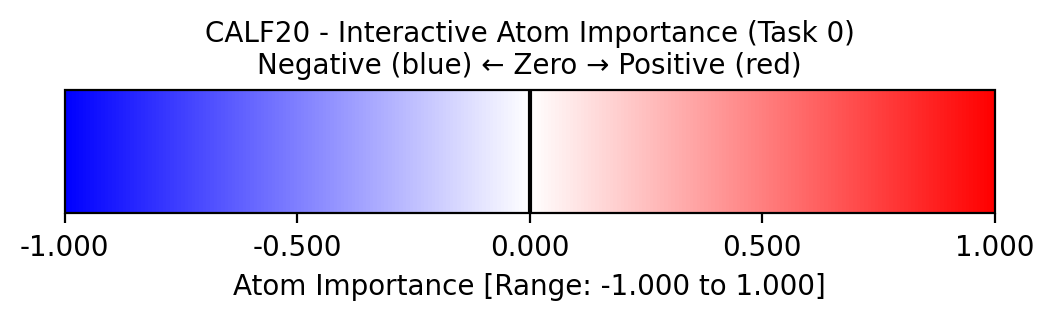

Visualization: CALF20 - Interactive Atom Importance (Task 0)
Total atoms: 44
Importance range: [-0.395, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 4

Interactive visualization controls:
- Left mouse: Rotate
- Right mouse: Zoom
- Middle mouse: Pan
- Double-click: Center on atom

## 7. Multi-task Comparison
Creating interactive comparison of tasks...
Comparison visualization using consistent color scale: [-1.000, 1.000]
Important atoms with high contribution values:
  Zn (atom 0): 0.991
  Zn (atom 1): 0.997
  Zn (atom 2): 1.000
  Zn (atom 3): 0.996
Click on atoms to see detailed importance values in the console


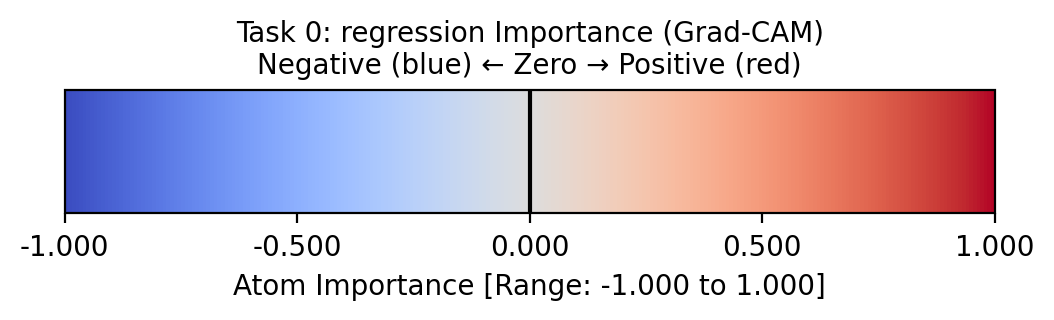

Visualization: Task 0: regression Importance (Grad-CAM)
Total atoms: 44
Importance range: [-0.395, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 4
Important atoms with high contribution values:
  H (atom 4): -0.705
  H (atom 5): -0.768
  H (atom 6): -0.769
  H (atom 7): -0.704
  H (atom 8): -0.730
  H (atom 9): -0.736
  H (atom 11): -0.731
  C (atom 18): 0.781
  C (atom 23): 0.767
  N (atom 24): -0.756
  N (atom 25): -1.000
  N (atom 26): -0.893
  N (atom 27): -0.895
  N (atom 28): -1.000
  N (atom 29): -0.804
  N (atom 30): -0.807
  N (atom 31): -0.956
  N (atom 32): -0.889
  N (atom 33): -0.874
  N (atom 34): -0.998
  N (atom 35): -0.810
Click on atoms to see detailed importance values in the console


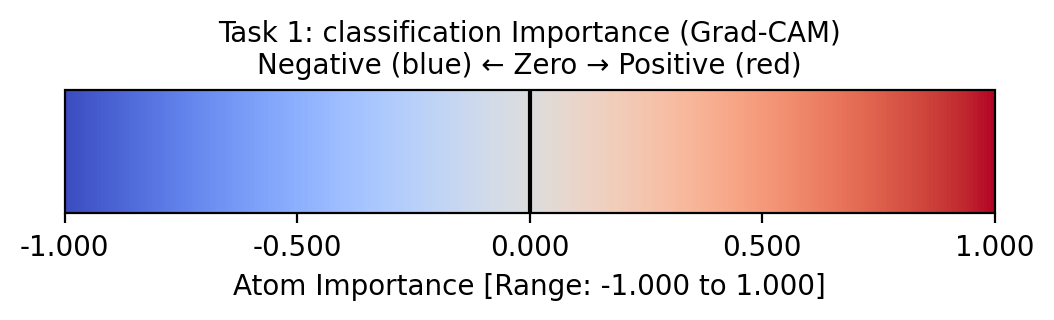

Visualization: Task 1: classification Importance (Grad-CAM)
Total atoms: 44
Importance range: [-1.000, 0.781]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 21
Important atoms with high contribution values:
  Zn (atom 0): -0.921
  Zn (atom 1): -0.921
  Zn (atom 2): -0.932
  Zn (atom 3): -0.929
  H (atom 4): 0.997
  H (atom 7): 1.000
  H (atom 8): 0.952
  H (atom 11): 0.956
  N (atom 24): -0.851
  N (atom 25): -0.965
  N (atom 28): -0.964
  N (atom 29): -0.859
  N (atom 30): -0.863
  N (atom 31): -0.955
  N (atom 34): -0.964
  N (atom 35): -0.861
Click on atoms to see detailed importance values in the console


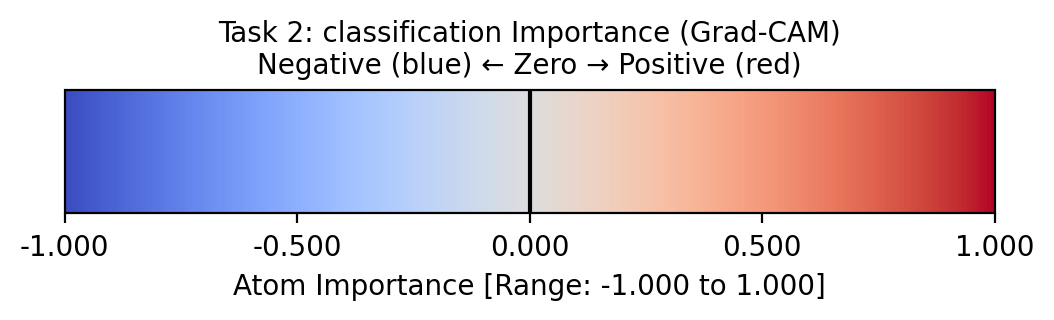

Visualization: Task 2: classification Importance (Grad-CAM)
Total atoms: 44
Importance range: [-0.965, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 16
Important atoms with high contribution values:
  H (atom 5): -0.803
  H (atom 6): -0.805
  H (atom 9): -0.756
  H (atom 10): -0.820
  N (atom 24): -0.805
  N (atom 25): -1.000
  N (atom 28): -0.999
  N (atom 29): -0.819
  N (atom 30): -0.827
  N (atom 31): -0.985
  N (atom 34): -1.000
  N (atom 35): -0.827
Click on atoms to see detailed importance values in the console


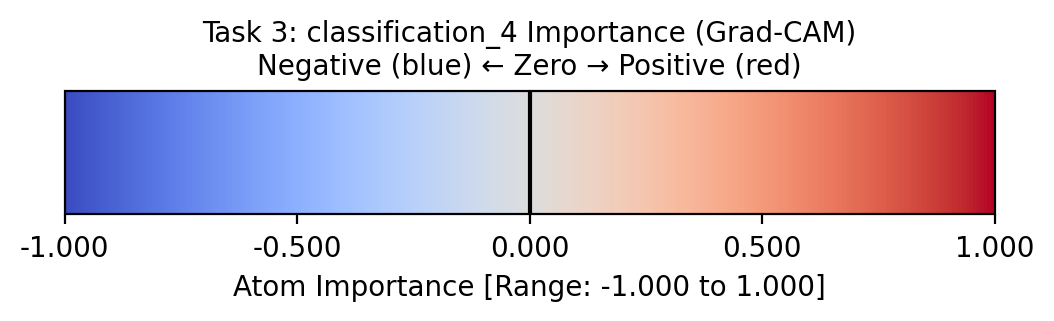

Visualization: Task 3: classification_4 Importance (Grad-CAM)
Total atoms: 44
Importance range: [-1.000, 0.272]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 12
Important atoms with high contribution values:
  H (atom 4): 0.784
  H (atom 5): 0.979
  H (atom 6): 0.981
  H (atom 7): 0.783
  H (atom 8): 0.843
  H (atom 9): 0.926
  H (atom 11): 0.847
  N (atom 24): 0.830
  N (atom 25): 1.000
  N (atom 28): 0.999
  N (atom 29): 0.847
  N (atom 30): 0.852
  N (atom 31): 0.980
  N (atom 34): 1.000
  N (atom 35): 0.853
Click on atoms to see detailed importance values in the console


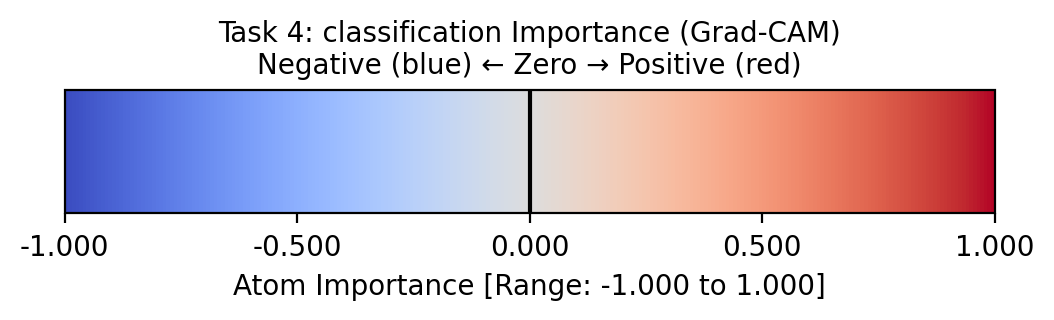

Visualization: Task 4: classification Importance (Grad-CAM)
Total atoms: 44
Importance range: [-0.179, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 15
Important atoms with high contribution values:
  H (atom 4): 0.739
  H (atom 5): 0.967
  H (atom 6): 0.969
  H (atom 7): 0.739
  H (atom 8): 0.800
  H (atom 9): 0.921
  H (atom 11): 0.804
  N (atom 24): 0.854
  N (atom 25): 0.999
  N (atom 28): 0.999
  N (atom 29): 0.851
  N (atom 30): 0.854
  N (atom 31): 0.998
  N (atom 33): 0.708
  N (atom 34): 1.000
  N (atom 35): 0.857
Click on atoms to see detailed importance values in the console


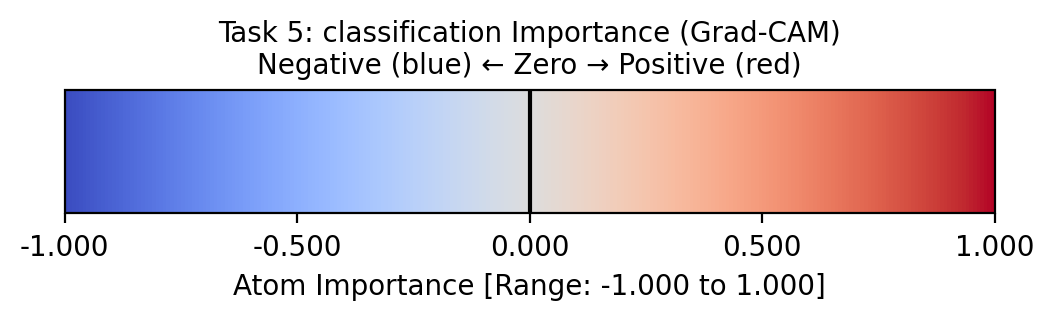

Visualization: Task 5: classification Importance (Grad-CAM)
Total atoms: 44
Importance range: [-0.181, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 16
Important atoms with high contribution values:
  H (atom 4): 0.832
  H (atom 5): 0.998
  H (atom 6): 1.000
  H (atom 7): 0.831
  H (atom 8): 0.886
  H (atom 9): 0.950
  H (atom 11): 0.887
  N (atom 25): 0.798
  N (atom 28): 0.797
  N (atom 31): 0.796
  N (atom 34): 0.798
Click on atoms to see detailed importance values in the console


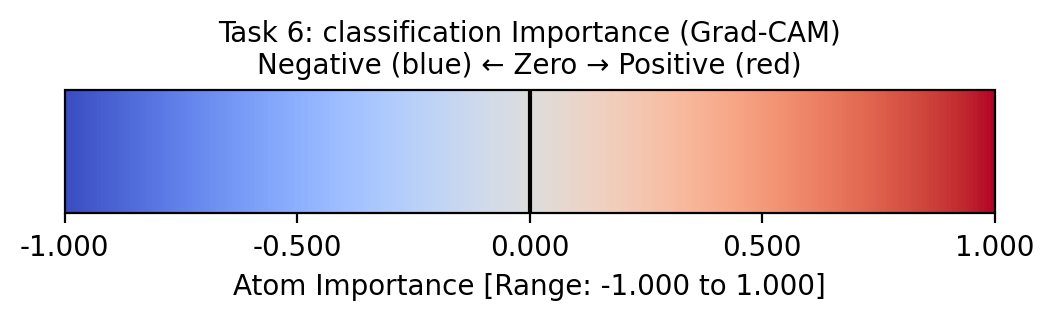

Visualization: Task 6: classification Importance (Grad-CAM)
Total atoms: 44
Importance range: [-0.256, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 11


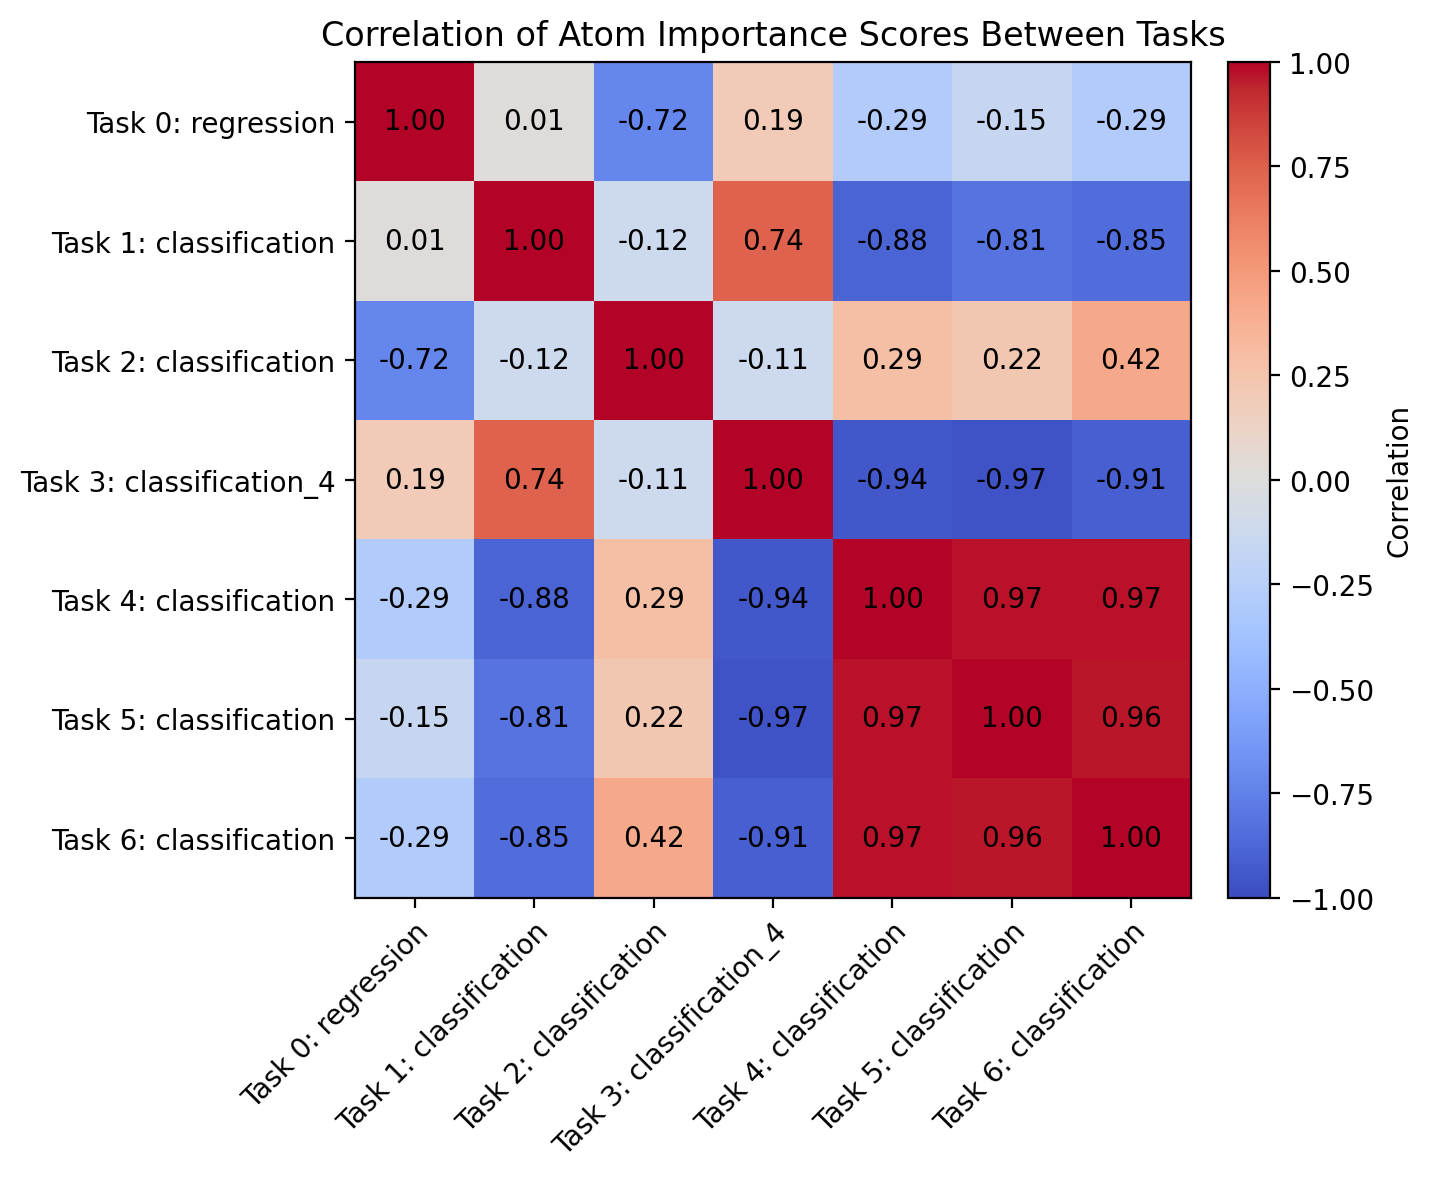

Created 7 interactive visualizations for comparison.

## 10. Conclusion
This notebook demonstrated how to visualize atom importance using:
1. Interactive 3D visualization with NGLView

These visualizations help interpret which atoms most influence the model's predictions.
The gradient-based importance calculation works even for models without attention mechanisms.


In [10]:

# Static Visualization
print("\n## 5. Static Matplotlib Visualization")
# Choose a task to visualize
task_idx = 0  # Change this to visualize different tasks

# Visualization parameters
figsize = (12, 10)
colormap = 'bwr'
highlight_threshold = 0.7

# # Check dimensions and ensure they match
# print(f"Atom coordinates shape: {atom_coords.shape}")
# print(f"Importance scores shape: {task_results[task_idx].shape}")
# print(f"Number of atom elements: {len(atom_elements)}")

# # Ensure all arrays have the same length
# min_length = min(len(atom_coords), len(task_results[task_idx]), len(atom_elements))
# atom_coords_vis = atom_coords[:min_length]
# importance_vis = task_results[task_idx][:min_length]
# atom_elements_vis = atom_elements[:min_length]

# print(f"Using {min_length} atoms for visualization")

# # Visualize atom importance for the selected task
# fig, ax = visualizer.visualize_atom_importance(
#     atom_coords_vis, importance_vis, 
#     atom_elements=atom_elements_vis,
#     figsize=figsize,
#     colormap=colormap,
#     title=f"{cif_id} - Atom Importance for Task {task_idx} ({model.task_types[task_idx]})",
#     highlight_threshold=highlight_threshold
# )

# plt.tight_layout()
# plt.show()

# Interactive Visualization
print("\n## 6. Interactive NGLView Visualization")
try:
    # Check if NGLView is available
    import nglview
    print("NGLView is available. Creating interactive visualization...")
    
    # Create an interactive visualization using NGLView
    ngl_view = visualizer.visualize_atom_importance(
        atoms=structure,
        atom_importance=task_results[task_idx],
        atom_elements=atom_elements,
        title=f"{cif_id} - Interactive Atom Importance (Task {task_idx})",
        colormap=colormap,
        highlight_threshold=highlight_threshold
    )
    
    if ngl_view is not None:
        print("\nInteractive visualization controls:")
        print("- Left mouse: Rotate")
        print("- Right mouse: Zoom")
        print("- Middle mouse: Pan")
        print("- Double-click: Center on atom")
    else:
        print("Failed to create NGLView visualization.")
except ImportError:
    print("NGLView is not installed. To enable interactive visualization, install it with:")
    print("pip install nglview")
except Exception as e:
    traceback.print_exc()


# Multi-task comparison (if multiple tasks available)
if len(model.task_types) > 1:
    print("\n## 7. Multi-task Comparison")
    try:
        import nglview
        print("Creating interactive comparison of tasks...")
        
        # Create a dictionary of task names and importance scores
        task_importance_dict = {}
        for idx, task_type in enumerate(model.task_types):
            task_importance_dict[f"Task {idx}: {task_type}"] = task_results[idx]
        
        # Create multi-task visualization with the simplified API
        views = visualizer.compare_task_importance(
            atoms=structure,
            task_importances=task_importance_dict,
            atom_elements=atom_elements,
            highlight_threshold=highlight_threshold
        )
        
        if views is not None:
            print(f"Created {len(views)} interactive visualizations for comparison.")
        else:
            print("Failed to create comparison visualizations.")
    except ImportError:
        print("NGLView is not installed. Multi-task comparison requires NGLView.")


print("\n## 10. Conclusion")
print("This notebook demonstrated how to visualize atom importance using:")
print("1. Interactive 3D visualization with NGLView")
print("\nThese visualizations help interpret which atoms most influence the model's predictions.")
print("The gradient-based importance calculation works even for models without attention mechanisms.")

In [11]:
ngl_view

NGLWidget()

In [20]:
# Export the visualization to HTML
print("\n## 9. Export Visualization to HTML")

# Check if we have a valid NGLView object
if 'ngl_view' in locals() and ngl_view is not None:
    
    # Generate HTML representation
    output_path = "mof_atom_importance_visualization.html"
    
    # Generate HTML content
    # html_content = ngl_view.write(output_path)
    nglview.write_html(output_path, ngl_view)
    # Save to file
    # with open(output_path, "w") as f:
    #     f.write(html_content)
    
    print(f"Visualization saved to: {output_path}")
    print("You can open this HTML file in any web browser to view the 3D structure.")
    print("Note: Some advanced interactive features may not work in the exported HTML.")
else:
    print("No valid NGLView object available to export.")


## 9. Export Visualization to HTML
Visualization saved to: mof_atom_importance_visualization.html
You can open this HTML file in any web browser to view the 3D structure.
Note: Some advanced interactive features may not work in the exported HTML.


In [13]:
import nglview